In [1]:
import datetime as dt
from lowres.loader import EarthDataLoader

loader = EarthDataLoader("S3B_SY_2_SYN")

/home/matteo/miniconda3/envs/earthaccess/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
bounding_box = 9, 43, 13, 46
start, end = dt.datetime(2024, 7, 16, 9, 0), dt.datetime(2024, 7, 16, 10, 0)

loader.search(start, end, bounding_box)

S3B_SY_2_SYN____20240716T094538_20240716T094838_20240717T133051_0179_095_193_2160_PS2_O_NT_002.zip


In [3]:
loader.pull('./.data')

QUEUEING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 1452.82it/s]
PROCESSING TASKS | : 100%|██████████| 1/1 [00:00<00:00, 5242.88it/s]
COLLECTING RESULTS | : 100%|██████████| 1/1 [00:00<00:00, 7049.25it/s]


In [4]:
results = loader.load_optical(bounding_box, 30, syn_sdr_bands=(8, 17), epsg_code='EPSG:32632')
xds = list(results.values())[0][0]
xds

.data/S3B_SY_2_SYN____20240716T094538_20240716T094838_20240717T133051_0179_095_193_2160_PS2_O_NT_002.SEN3


<xarray.Dataset> Size: 1GB
Dimensions:      (x: 10870, y: 11368, band: 2)
Coordinates:
  * x            (x) float64 87kB 5e+05 5e+05 5.001e+05 ... 8.26e+05 8.261e+05
  * y            (y) float64 91kB 5.102e+06 5.102e+06 ... 4.761e+06 4.761e+06
  * band         (band) <U4 32B 'Oa08' 'Oa17'
    spatial_ref  int64 8B 0
Data variables:
    SDR          (band, y, x) float32 989MB nan nan nan ... 0.3692 0.3692 0.3692
    CLOUD_flags  (y, x) uint8 124MB 1 1 1 1 1 1 1 1 1 1 ... 0 0 0 0 0 0 0 0 0 0
    OLC_flags    (y, x) uint16 247MB 4352 4352 4352 4352 ... 4100 4100 4100 4100

In [5]:
def plot(data, bbox):

    for xda in data:
        assert xda.rio.crs.to_dict()['proj'] == 'utm', "Data must be in UTM projection"

    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import geopandas as gpd
    from shapely.geometry import box

    epsg = xda.rio.crs.to_string()
    zone = xda.rio.crs.to_dict()['zone']
    hemisphere = xda.rio.crs.to_wkt().split(f'WGS 84 / UTM zone {zone}')[1][0]
    crs_utm = ccrs.UTM(zone, southern_hemisphere=hemisphere=='S')

    plt.figure(figsize=(15, 5))

    utm_box = gpd.GeoSeries([box(*bbox)], crs='EPSG:4326').to_crs(epsg).envelope
    utm_bounds = utm_box.total_bounds
    buf = ((utm_bounds[2] - utm_bounds[0]) + (utm_bounds[3] - utm_bounds[1])) / 2 / 10
    utm_bounds_buf = gpd.GeoDataFrame(geometry=utm_box).buffer(buf).total_bounds

    ax = plt.axes(projection=crs_utm)

    for xda in data:
        xda.plot.pcolormesh(y='y', x='x', ax=ax, cmap=xda.attrs['cmap'], transform=crs_utm)  
    
    ax.coastlines()
    ax.set_global()
    ax.set_ylim(utm_bounds_buf[1], utm_bounds_buf[3])
    ax.set_xlim(utm_bounds_buf[0], utm_bounds_buf[2])

    utm_box.plot(ax=ax, facecolor="none", edgecolor="blue")

In [6]:
red = xds.SDR.sel(band='Oa08').where(xds.SDR.sel(band='Oa08')>0)
nir = xds.SDR.sel(band='Oa17').where(xds.SDR.sel(band='Oa17')>0)
ndvi = ((nir-red)/(nir+red)).clip(0, 1).rename('NDVI')
ndvi.attrs['cmap'] = 'OrRd'

flags = xds.OLC_flags.rename('OLCI Q&C flags')
flags.attrs.pop('long_name', None)
flags.attrs.pop('standard_name', None)
flags.attrs['cmap'] = 'Blues_r'

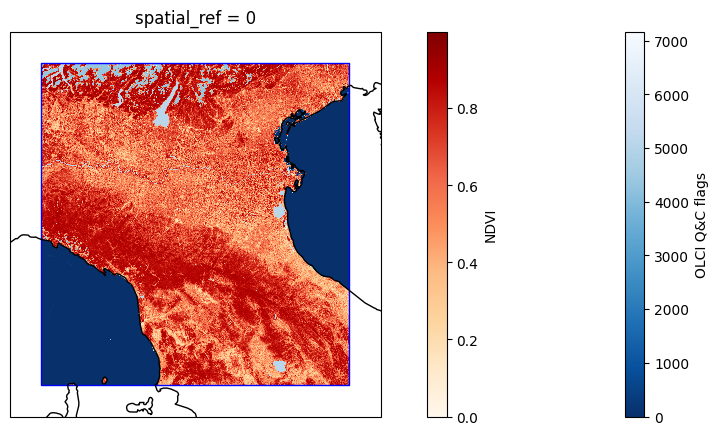

In [7]:
plot((flags, ndvi), bounding_box)